# Welcome to Modal notebooks!

Write Python code and collaborate in real time. Your code runs in Modal's
**serverless cloud**, and anyone in the same workspace can join.

This notebook comes with some common Python libraries installed. Run
cells with `Shift+Enter`.

In [1]:
# ====== CELL 0: Install Semua Library (WAJIB di Modal.com) ======
import subprocess
subprocess.run(["pip", "install", "-q",
    "opencv-python-headless",  # bukan opencv-python, lebih stabil di server
    "albumentations",
    "scipy",
    "pandas",
    "seaborn",
    "scikit-learn",
    "gdown",
    "torchvision",
], check=True)

print("Semua library berhasil diinstall!")

Semua library berhasil diinstall!



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Random seed dikunci: 42


Downloading...
From (original): https://drive.google.com/uc?id=1EKaulZi4MLy9sxJyilWjiY-ZSTe-H9dB
From (redirected): https://drive.google.com/uc?id=1EKaulZi4MLy9sxJyilWjiY-ZSTe-H9dB&confirm=t&uuid=ebe0f662-f10f-4a4b-b352-8294db5b6e17
To: /root/fuseg_dataset.zip
100%|███████████████████████████████████████████████████████████████████████| 248M/248M [00:03<00:00, 63.3MB/s]


Extracting ZIP...
Selesai! Struktur folder:
dataset/ (0 files)
  train/ (0 files)
    labels/ (810 files)
    images/ (810 files)
  validation/ (0 files)
    labels/ (200 files)
    images/ (200 files)

Train images : 810
Train masks  : 810
Val images   : 200
Val masks    : 200
Train: 810 gambar
Test (semua val): 200 gambar
Train aktual      : 729 gambar
Val monitoring    : 81 gambar
Test set (final)  : 200 gambar (semua validation FUSeg)
Train batches    : 183
Val batches      : 21
Test batches     : 50
Device: cuda
GPU   : NVIDIA L40S

  Melatih: BASELINE (Dice Loss)
  Epochs : 60
  Device : cuda



/tmp/ipykernel_338/3357998580.py:156: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 15.0), p=0.2),


  Epoch [  1/60] Train Dice=0.0661  Val Dice=0.2386  Val IoU=0.1395  LR=9.99e-05
  Epoch [  5/60] Train Dice=0.4630  Val Dice=0.5963  Val IoU=0.4315  LR=9.83e-05
  Epoch [ 10/60] Train Dice=0.6761  Val Dice=0.7616  Val IoU=0.6302  LR=9.34e-05
  Epoch [ 15/60] Train Dice=0.8096  Val Dice=0.8727  Val IoU=0.7784  LR=8.55e-05
  Epoch [ 20/60] Train Dice=0.8752  Val Dice=0.8517  Val IoU=0.7559  LR=7.52e-05
  Epoch [ 25/60] Train Dice=0.8965  Val Dice=0.8854  Val IoU=0.8085  LR=6.33e-05
  Epoch [ 30/60] Train Dice=0.9054  Val Dice=0.8924  Val IoU=0.8176  LR=5.05e-05
  Epoch [ 35/60] Train Dice=0.9146  Val Dice=0.8956  Val IoU=0.8233  LR=3.77e-05
  Epoch [ 40/60] Train Dice=0.9206  Val Dice=0.8985  Val IoU=0.8264  LR=2.58e-05
  Epoch [ 45/60] Train Dice=0.9230  Val Dice=0.8975  Val IoU=0.8264  LR=1.55e-05
  Epoch [ 50/60] Train Dice=0.9239  Val Dice=0.8983  Val IoU=0.8264  LR=7.63e-06
  Epoch [ 55/60] Train Dice=0.9272  Val Dice=0.8976  Val IoU=0.8267  LR=2.69e-06
  Epoch [ 60/60] Train Dice=

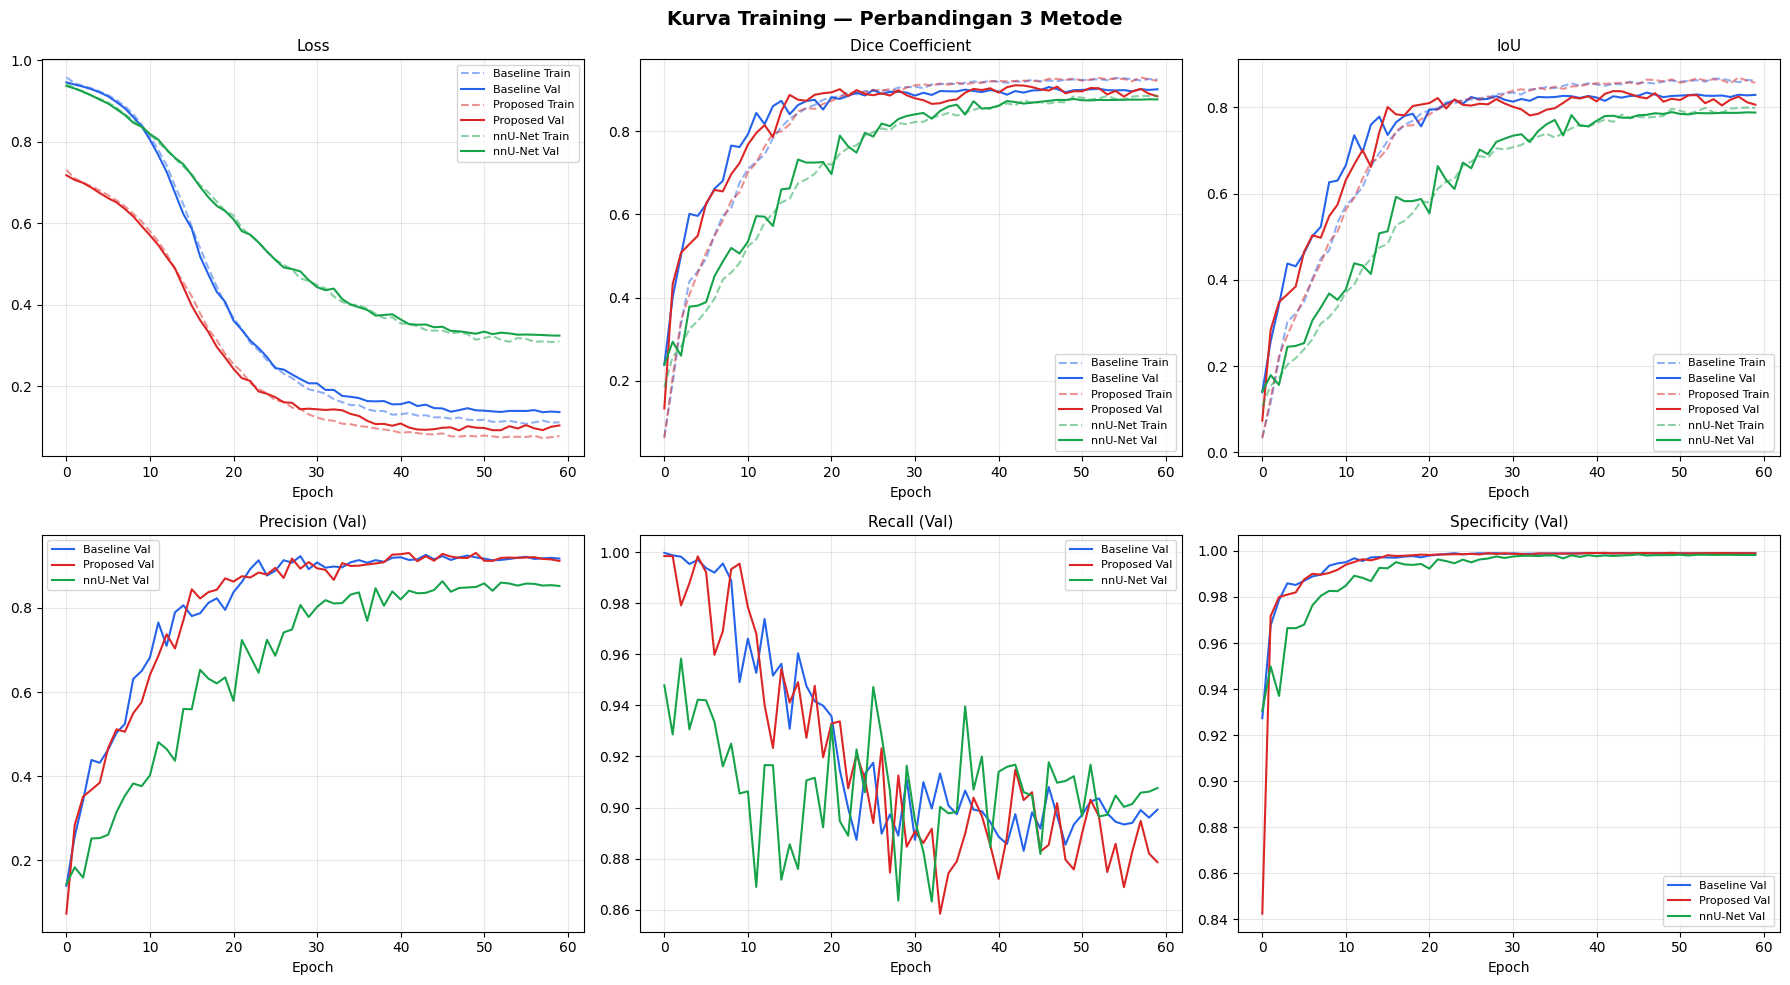

Gambar disimpan: /root/results/training_curves.png


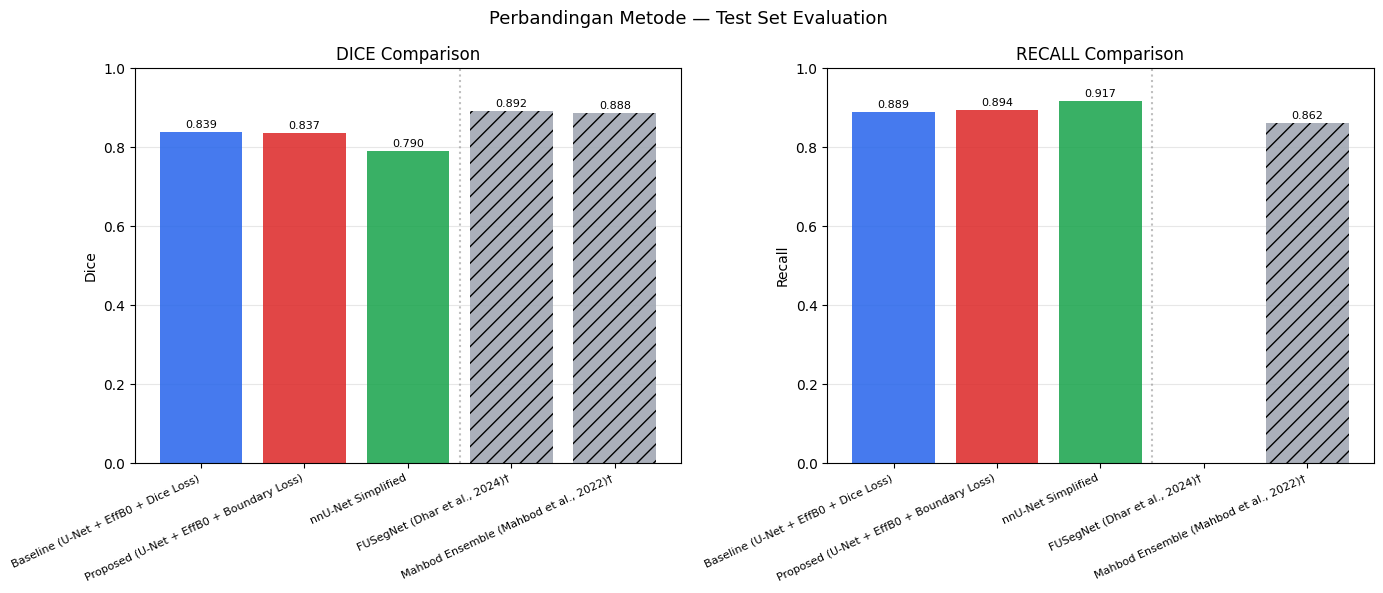

Gambar disimpan: /root/results/bar_comparison.png
Gambar disimpan: /root/results/visual_predictions.png


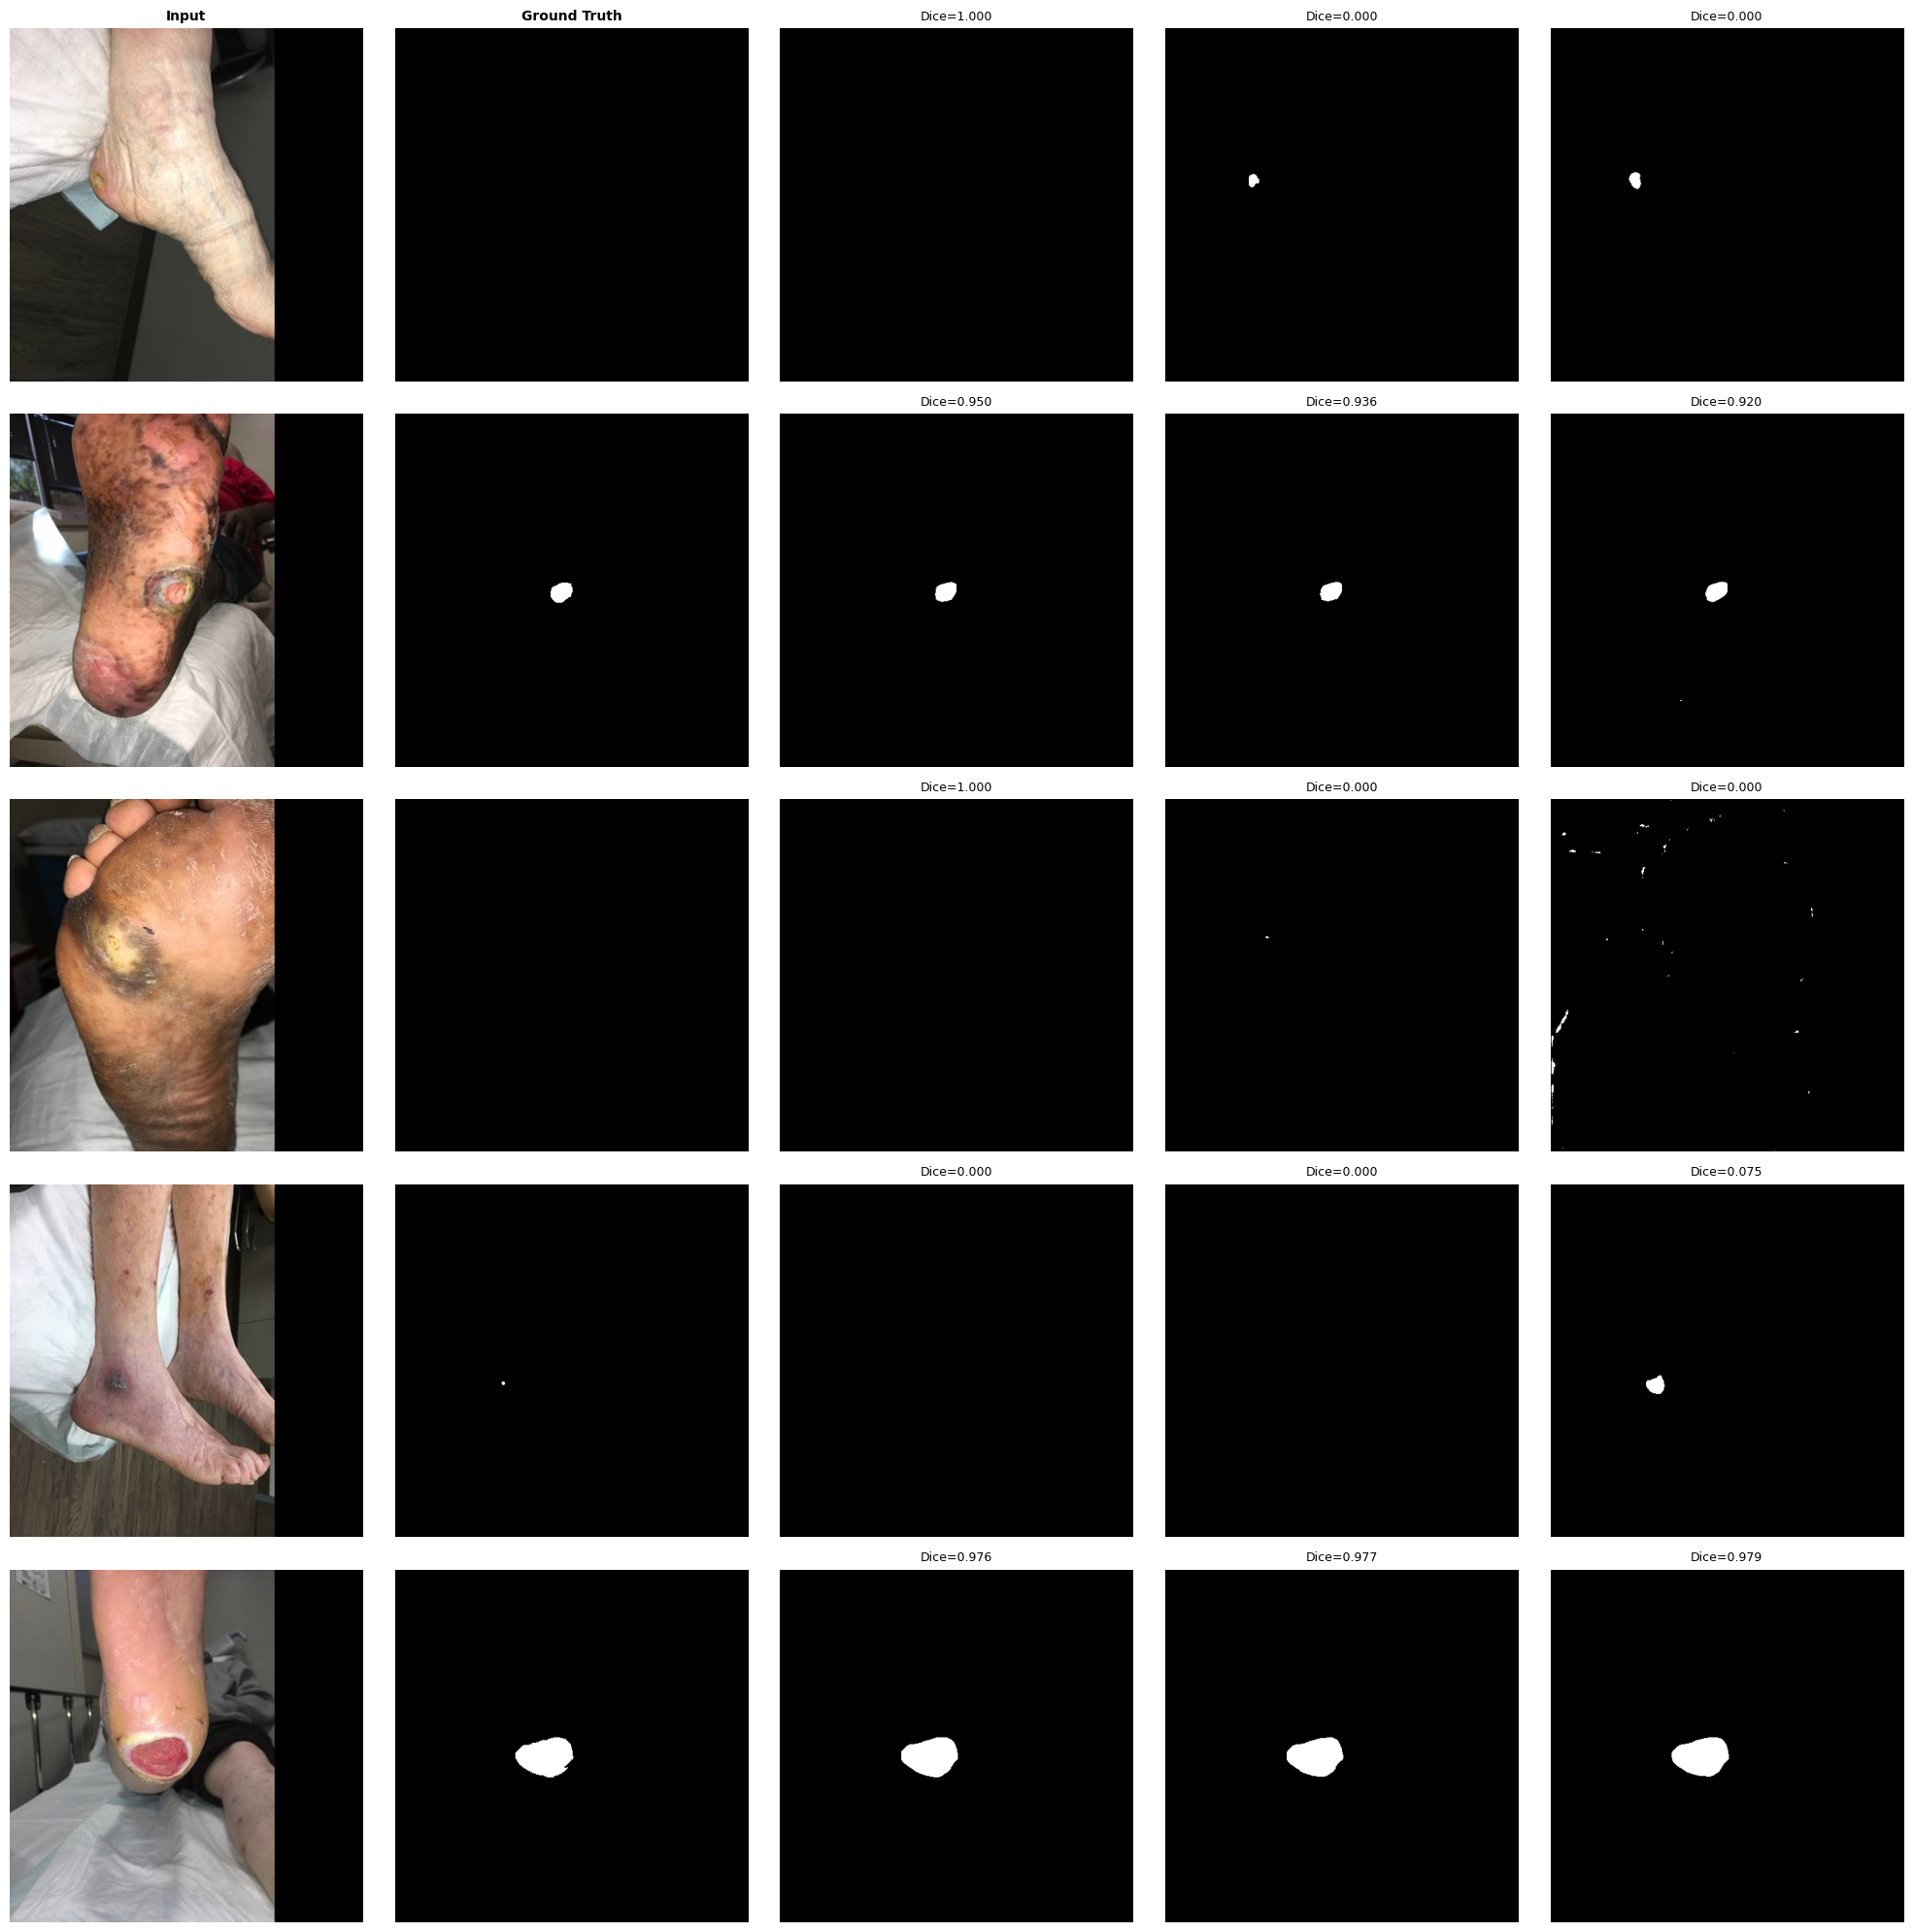


  ANALISIS PER UKURAN ULKUS

Analisis per ukuran ulkus — Baseline
Kelompok        N   Dice Mean    Dice Std
------------------------------------------
  0%            5      0.4000      0.4899
  <1%         123      0.8057      0.2273
  1-5%         65      0.9267      0.0745
  5-15%         7      0.9194      0.0614

Analisis per ukuran ulkus — Proposed
Kelompok        N   Dice Mean    Dice Std
------------------------------------------
  0%            5      0.0000      0.0000
  <1%         123      0.8219      0.2085
  1-5%         65      0.9245      0.0763
  5-15%         7      0.8887      0.1628

Analisis per ukuran ulkus — nnU-Net
Kelompok        N   Dice Mean    Dice Std
------------------------------------------
  0%            5      0.0000      0.0000
  <1%         123      0.7607      0.2390
  1-5%         65      0.9071      0.0925
  5-15%         7      0.7865      0.2359

Menyimpan semua file ke Google Drive...
  ✓ baseline_best.pth
  ✓ proposed_best.pth
  ✓ nnunet_bes

In [3]:
# ============================================================
# TUGAS AKHIR - SEGMENTASI ULKUS KAKI DIABETIK
# Riodino Raihan
# U-Net + EfficientNet-B0 dengan Boundary Refinement Loss
#
# STRUKTUR EKSPERIMEN:
#   - Baseline  : U-Net + EfficientNet-B0 + Dice Loss
#   - Proposed  : U-Net + EfficientNet-B0 + Combined Loss (Dice + Boundary)
#   - nnU-Net   : Simplified nnU-Net style architecture
#   - Referensi : FUSegNet (Dhar et al.) & Mahbod Ensemble (dari paper)
#
# DATASET SPLIT:
#   - Train : 810 gambar (semua train FUSeg)
#   - Val   : subset kecil dari train untuk monitoring (tidak ada test leak)
#   - Test  : 200 gambar validation FUSeg (SEMUA dipakai sebagai test set)
#
# CATATAN REPRODUKSI:
#   Random seed dikunci di semua komponen (torch, numpy, python random)
#   sehingga hasil dapat direproduksi.
# ============================================================

# ====== CELL 1: Install ======
# Jalankan ini sekali di awal sesi Colab
# !pip install -q albumentations opencv-python scipy pandas seaborn

# ====== CELL 2: Import ======
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.ndimage as ndi
from scipy.spatial.distance import directed_hausdorff

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# ====== CELL 3: Seed untuk Reprodusibilitas ======
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Untuk konvolusi deterministik (sedikit lebih lambat, tapi reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f"Random seed dikunci: {SEED}")

import gdown
import zipfile
import os

# Ganti dengan FILE_ID zip Anda
# https://drive.google.com/file/d/1EKaulZi4MLy9sxJyilWjiY-ZSTe-H9dB/view?usp=sharing
ZIP_FILE_ID = "1EKaulZi4MLy9sxJyilWjiY-ZSTe-H9dB"

print("Downloading ZIP...")
gdown.download(
    f"https://drive.google.com/uc?id={ZIP_FILE_ID}",
    "/root/fuseg_dataset.zip",
    quiet=False
)

print("Extracting ZIP...")
with zipfile.ZipFile("/root/fuseg_dataset.zip", "r") as zf:
    zf.extractall("/root/dataset/")

print("Selesai! Struktur folder:")
for root, dirs, files in os.walk("/root/dataset"):
    level = root.replace("/root/dataset", "").count(os.sep)
    if level < 3:
        indent = " " * 2 * level
        print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")

# Set path
BASE_DIR       = "/root/dataset"
TRAIN_IMG_DIR  = os.path.join(BASE_DIR, "train/images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train/labels")
VAL_IMG_DIR    = os.path.join(BASE_DIR, "validation/images")
VAL_MASK_DIR   = os.path.join(BASE_DIR, "validation/labels")
RESULTS_DIR    = "/root/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\nTrain images : {len(os.listdir(TRAIN_IMG_DIR))}")
print(f"Train masks  : {len(os.listdir(TRAIN_MASK_DIR))}")
print(f"Val images   : {len(os.listdir(VAL_IMG_DIR))}")
print(f"Val masks    : {len(os.listdir(VAL_MASK_DIR))}")
# Verifikasi
train_imgs = sorted(os.listdir(TRAIN_IMG_DIR))
val_imgs   = sorted(os.listdir(VAL_IMG_DIR))
print(f"Train: {len(train_imgs)} gambar")
print(f"Test (semua val): {len(val_imgs)} gambar")

# ====== CELL 6: Split Train → Train + Val Kecil untuk Monitoring ======
# 90% training, 10% monitoring (val ini BUKAN test set)
# Test set = SEMUA 200 gambar validation FUSeg
train_list, val_monitor_list = train_test_split(
    train_imgs, test_size=0.1, random_state=SEED
)
print(f"Train aktual      : {len(train_list)} gambar")
print(f"Val monitoring    : {len(val_monitor_list)} gambar")
print(f"Test set (final)  : {len(val_imgs)} gambar (semua validation FUSeg)")

# ====== CELL 7: Dataset Class ======
class FootUlcerDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_list=None, transform=None):
        self.image_dir  = image_dir
        self.mask_dir   = mask_dir
        self.images     = image_list if image_list else sorted(os.listdir(image_dir))
        self.transform  = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname    = self.images[idx]
        img_path = os.path.join(self.image_dir, fname)
        msk_path = os.path.join(self.mask_dir, fname)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        mask  = (mask > 0).astype(np.float32)

        if self.transform:
            out   = self.transform(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"].unsqueeze(0)
        return image, mask

# ====== CELL 8: Augmentasi ======
# Train: augmentasi sedang (tidak berlebihan agar tidak destabilisasi kurva)
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    A.GaussNoise(var_limit=(5.0, 15.0), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Val/Test: hanya resize + normalize, tidak ada augmentasi
val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ====== CELL 9: DataLoader ======
BATCH_SIZE  = 4     # Turunkan ke 4 agar memory aman dengan input 512x512
NUM_WORKERS = 2

train_dataset   = FootUlcerDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR,
                                   image_list=train_list, transform=train_transform)
val_dataset     = FootUlcerDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR,
                                   image_list=val_monitor_list, transform=val_transform)
test_dataset    = FootUlcerDataset(VAL_IMG_DIR, VAL_MASK_DIR,
                                   transform=val_transform)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, worker_init_fn=seed_worker,
                          generator=g, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches    : {len(train_loader)}")
print(f"Val batches      : {len(val_loader)}")
print(f"Test batches     : {len(test_loader)}")

# ====== CELL 10: Building Blocks Arsitektur ======
class ConvBnReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pad=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            ConvBnReLU(in_ch, out_ch),
            ConvBnReLU(out_ch, out_ch)
        )
    def forward(self, x):
        return self.block(x)

class DecoderBlock(nn.Module):
    """Upsample → concat skip → DoubleConv"""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Pad jika ukuran tidak tepat (bisa terjadi karena stride)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

# ====== CELL 11: Model 1 & 2 — U-Net + EfficientNet-B0 ======
class UNetEfficientNetB0(nn.Module):
    """
    Encoder : EfficientNet-B0 pretrained (ImageNet)
    Decoder : Custom decoder dengan skip connections
    Output  : Sigmoid untuk segmentasi biner
    """
    def __init__(self, num_classes=1):
        super().__init__()
        backbone    = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.encoder = backbone.features  # 9 blok

        # Channel referensi EfficientNet-B0:
        # features[0] : stem → 32ch
        # features[1] : MBConv1 → 16ch
        # features[2] : MBConv6 → 24ch
        # features[3] : MBConv6 → 40ch
        # features[5] : MBConv6 → 112ch
        # features[8] : Conv head → 1280ch

        # Decoder
        self.dec4 = DecoderBlock(1280, 112, 256)
        self.dec3 = DecoderBlock(256,  40,  128)
        self.dec2 = DecoderBlock(128,  24,  64)
        self.dec1 = DecoderBlock(64,   16,  32)
        self.dec0 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.head = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        feats = []
        for layer in self.encoder:
            x = layer(x)
            feats.append(x)

        # Skip connections (indeks mengikuti fitur EfficientNet-B0)
        e1 = feats[1]   # 16ch
        e2 = feats[2]   # 24ch
        e3 = feats[3]   # 40ch
        e4 = feats[5]   # 112ch
        e5 = feats[-1]  # 1280ch (bottleneck)

        d4 = self.dec4(e5, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)
        d0 = self.dec0(d1)
        return torch.sigmoid(self.head(d0))

# ====== CELL 12: Model 3 — Simplified nnU-Net Style ======
class ResBlock(nn.Module):
    """Residual block: dua ConvBnReLU + shortcut"""
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            ConvBnReLU(ch, ch),
            ConvBnReLU(ch, ch)
        )
        self.shortcut = nn.Identity()

    def forward(self, x):
        return F.relu(self.block(x) + self.shortcut(x), inplace=True)

class NNUNetSimplified(nn.Module):
    """
    Simplified nnU-Net style:
    - Encoder dengan residual blocks (terinspirasi dari nnU-Net versi residual)
    - Decoder dengan ConvTranspose2d + skip connections
    - Instance Normalization (seperti nnU-Net asli, bukan BatchNorm)

    Referensi: Hresko et al. (2023) - Refined Mixup Augmentation for DFU Segmentation
    yang juga memakai nnU-Net sebagai backbone dengan short skip connections.
    Implementasi ini adalah versi sederhana yang bisa dijalankan di Colab.
    """
    def __init__(self, in_ch=3, num_classes=1, base_ch=32):
        super().__init__()
        f = base_ch  # 32

        # Encoder
        self.enc1 = self._make_block(in_ch, f)
        self.enc2 = self._make_block(f,     f*2)
        self.enc3 = self._make_block(f*2,   f*4)
        self.enc4 = self._make_block(f*4,   f*8)
        self.enc5 = self._make_block(f*8,   f*16)  # Bottleneck

        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.up4  = nn.ConvTranspose2d(f*16, f*8,  kernel_size=2, stride=2)
        self.dec4 = self._make_block(f*16, f*8)

        self.up3  = nn.ConvTranspose2d(f*8,  f*4,  kernel_size=2, stride=2)
        self.dec3 = self._make_block(f*8,  f*4)

        self.up2  = nn.ConvTranspose2d(f*4,  f*2,  kernel_size=2, stride=2)
        self.dec2 = self._make_block(f*4,  f*2)

        self.up1  = nn.ConvTranspose2d(f*2,  f,    kernel_size=2, stride=2)
        self.dec1 = self._make_block(f*2,  f)

        self.head = nn.Conv2d(f, num_classes, kernel_size=1)

    def _make_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e5 = self.enc5(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(e5), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.sigmoid(self.head(d1))

# ====== CELL 13: Loss Functions ======
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        p = preds.view(-1)
        t = targets.view(-1)
        inter = (p * t).sum()
        return 1 - (2. * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)

class BoundaryLoss(nn.Module):
    """
    Boundary-aware loss: mendorong prediksi akurat di area tepi ulkus.
    Menggunakan distance transform dari ground truth mask.
    Terinspirasi dari: Yi et al. (2023) - OCRNet with boundary loss untuk DFU.
    """
    def __init__(self):
        super().__init__()

    def forward(self, preds, targets):
        preds_sq   = preds.squeeze(1)
        targets_sq = targets.squeeze(1)

        dist_maps = []
        for t in targets_sq.cpu().numpy():
            # Jarak dari setiap piksel ke batas terdekat ulkus
            dist = ndi.distance_transform_edt(1 - t)
            # Normalisasi agar gradiennya stabil
            if dist.max() > 0:
                dist = dist / dist.max()
            dist_maps.append(dist)

        dist_tensor = torch.tensor(
            np.stack(dist_maps), dtype=torch.float32, device=preds.device
        )
        # Hukum prediksi positif yang jauh dari tepi ulkus (false positives di area background)
        return torch.mean(preds_sq * dist_tensor)

class CombinedLoss(nn.Module):
    """
    Gabungan Dice Loss + Boundary Loss.
    alpha: bobot untuk Dice Loss (default 0.7)
    """
    def __init__(self, alpha=0.7):
        super().__init__()
        self.dice     = DiceLoss()
        self.boundary = BoundaryLoss()
        self.alpha    = alpha

    def forward(self, preds, targets):
        return self.alpha * self.dice(preds, targets) + (1 - self.alpha) * self.boundary(preds, targets)

# ====== CELL 14: Metric Functions ======
def dice_coefficient(preds, targets, smooth=1e-6):
    preds   = (preds > 0.5).float().view(-1)
    targets = targets.view(-1)
    inter   = (preds * targets).sum()
    return ((2. * inter + smooth) / (preds.sum() + targets.sum() + smooth)).item()

def iou_score(preds, targets, smooth=1e-6):
    preds   = (preds > 0.5).float().view(-1)
    targets = targets.view(-1)
    inter   = (preds * targets).sum()
    union   = preds.sum() + targets.sum() - inter
    return ((inter + smooth) / (union + smooth)).item()

def precision_recall_specificity(preds, targets, smooth=1e-6):
    preds   = (preds > 0.5).float().view(-1).cpu().numpy()
    targets = targets.view(-1).cpu().numpy()
    tp = ((preds == 1) & (targets == 1)).sum()
    fp = ((preds == 1) & (targets == 0)).sum()
    tn = ((preds == 0) & (targets == 0)).sum()
    fn = ((preds == 0) & (targets == 1)).sum()
    precision   = (tp + smooth) / (tp + fp + smooth)
    recall      = (tp + smooth) / (tp + fn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)
    return float(precision), float(recall), float(specificity)

def hausdorff_distance(pred, target):
    pred_bin = (pred > 0.5).cpu().numpy()
    tgt_bin  = target.cpu().numpy()
    pred_pts = np.argwhere(pred_bin)
    tgt_pts  = np.argwhere(tgt_bin)
    if len(pred_pts) == 0 or len(tgt_pts) == 0:
        return None
    hd = max(
        directed_hausdorff(pred_pts, tgt_pts)[0],
        directed_hausdorff(tgt_pts, pred_pts)[0]
    )
    return hd

# ====== CELL 15: Training Loop ======
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    ep_loss, ep_dice, ep_iou = 0., 0., 0.
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, masks)
        loss.backward()
        # Gradient clipping — mencegah ledakan gradien, menstabilkan kurva
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        ep_loss += loss.item()
        ep_dice += dice_coefficient(outputs.detach(), masks)
        ep_iou  += iou_score(outputs.detach(), masks)
    n = len(loader)
    return ep_loss/n, ep_dice/n, ep_iou/n

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    sums = {'loss':0,'dice':0,'iou':0,'prec':0,'rec':0,'spec':0}
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            sums['loss'] += criterion(outputs, masks).item()
            sums['dice'] += dice_coefficient(outputs, masks)
            sums['iou']  += iou_score(outputs, masks)
            p, r, s = precision_recall_specificity(outputs, masks)
            sums['prec'] += p
            sums['rec']  += r
            sums['spec'] += s
    n = len(loader)
    return {k: v/n for k, v in sums.items()}

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, device, save_path, model_name="Model"):
    best_dice  = 0.0
    best_epoch = 0
    history    = {k: [] for k in [
        'train_loss','train_dice','train_iou',
        'val_loss','val_dice','val_iou',
        'val_prec','val_rec','val_spec','lr'
    ]}

    print(f"\n{'='*60}")
    print(f"  Melatih: {model_name}")
    print(f"  Epochs : {num_epochs}")
    print(f"  Device : {device}")
    print(f"{'='*60}\n")

    for epoch in range(num_epochs):
        set_seed(SEED + epoch)  # Seed per-epoch agar augmentasi reproducible

        tr_loss, tr_dice, tr_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_m = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(tr_loss)
        history['train_dice'].append(tr_dice)
        history['train_iou'].append(tr_iou)
        history['val_loss'].append(val_m['loss'])
        history['val_dice'].append(val_m['dice'])
        history['val_iou'].append(val_m['iou'])
        history['val_prec'].append(val_m['prec'])
        history['val_rec'].append(val_m['rec'])
        history['val_spec'].append(val_m['spec'])
        history['lr'].append(current_lr)

        if val_m['dice'] > best_dice:
            best_dice  = val_m['dice']
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:3d}/{num_epochs}] "
                  f"Train Dice={tr_dice:.4f}  "
                  f"Val Dice={val_m['dice']:.4f}  "
                  f"Val IoU={val_m['iou']:.4f}  "
                  f"LR={current_lr:.2e}")

    print(f"\n  [Best] Val Dice = {best_dice:.4f} pada Epoch {best_epoch}")
    return history, best_dice, best_epoch

# ====== CELL 16: Test Set Evaluation ======
def evaluate_on_test(model, loader, device):
    model.eval()
    all_dice, all_iou     = [], []
    all_prec, all_rec     = [], []
    all_spec, all_hd      = [], []

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            for i in range(outputs.shape[0]):
                all_dice.append(dice_coefficient(outputs[i], masks[i]))
                all_iou.append(iou_score(outputs[i], masks[i]))
                p, r, s = precision_recall_specificity(outputs[i], masks[i])
                all_prec.append(p)
                all_rec.append(r)
                all_spec.append(s)
                hd = hausdorff_distance(outputs[i][0], masks[i][0])
                if hd is not None:
                    all_hd.append(hd)

    results = {
        'dice'      : {'mean': np.mean(all_dice),  'std': np.std(all_dice)},
        'iou'       : {'mean': np.mean(all_iou),   'std': np.std(all_iou)},
        'precision' : {'mean': np.mean(all_prec),  'std': np.std(all_prec)},
        'recall'    : {'mean': np.mean(all_rec),   'std': np.std(all_rec)},
        'specificity':{'mean': np.mean(all_spec),  'std': np.std(all_spec)},
        'hausdorff' : {'mean': np.mean(all_hd) if all_hd else 0.0,
                       'std' : np.std(all_hd)  if all_hd else 0.0},
    }
    return results

# ====== CELL 17: Setup Device ======
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

# Hyperparameter
NUM_EPOCHS_BASE = 60
NUM_EPOCHS_PROP = 60
NUM_EPOCHS_NNUN = 60
LR              = 1e-4   # Lebih rendah dari sebelumnya agar kurva stabil

# ====== CELL 18: Training — Baseline ======
set_seed(SEED)
baseline_model = UNetEfficientNetB0().to(device)
baseline_crit  = DiceLoss()
baseline_optim = optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)
baseline_sched = CosineAnnealingLR(baseline_optim, T_max=NUM_EPOCHS_BASE, eta_min=1e-6)

baseline_save  = os.path.join(RESULTS_DIR, "baseline_best.pth")
baseline_hist, baseline_best, baseline_ep = train_model(
    baseline_model, train_loader, val_loader,
    baseline_crit, baseline_optim, baseline_sched,
    NUM_EPOCHS_BASE, device, baseline_save, "BASELINE (Dice Loss)"
)

# ====== CELL 19: Training — Proposed ======
set_seed(SEED)
proposed_model = UNetEfficientNetB0().to(device)
proposed_crit  = CombinedLoss(alpha=0.7)
proposed_optim = optim.AdamW(proposed_model.parameters(), lr=LR, weight_decay=1e-4)
proposed_sched = CosineAnnealingLR(proposed_optim, T_max=NUM_EPOCHS_PROP, eta_min=1e-6)

proposed_save  = os.path.join(RESULTS_DIR, "proposed_best.pth")
proposed_hist, proposed_best, proposed_ep = train_model(
    proposed_model, train_loader, val_loader,
    proposed_crit, proposed_optim, proposed_sched,
    NUM_EPOCHS_PROP, device, proposed_save, "PROPOSED (Combined Loss)"
)

# ====== CELL 20: Training — nnU-Net Simplified ======
set_seed(SEED)
nnunet_model = NNUNetSimplified(in_ch=3, num_classes=1, base_ch=32).to(device)
nnunet_crit  = DiceLoss()
nnunet_optim = optim.AdamW(nnunet_model.parameters(), lr=LR, weight_decay=1e-4)
nnunet_sched = CosineAnnealingLR(nnunet_optim, T_max=NUM_EPOCHS_NNUN, eta_min=1e-6)

nnunet_save  = os.path.join(RESULTS_DIR, "nnunet_best.pth")
nnunet_hist, nnunet_best, nnunet_ep = train_model(
    nnunet_model, train_loader, val_loader,
    nnunet_crit, nnunet_optim, nnunet_sched,
    NUM_EPOCHS_NNUN, device, nnunet_save, "nnU-Net Simplified"
)

# ====== CELL 21: Load Best Weights & Evaluate on Test Set ======
print("\n" + "="*60)
print("  EVALUASI PADA TEST SET (200 gambar validation FUSeg)")
print("="*60)

baseline_model.load_state_dict(torch.load(baseline_save, map_location=device))
proposed_model.load_state_dict(torch.load(proposed_save, map_location=device))
nnunet_model.load_state_dict(torch.load(nnunet_save, map_location=device))

print("\nEvaluasi Baseline...")
baseline_res = evaluate_on_test(baseline_model, test_loader, device)
print("Evaluasi Proposed...")
proposed_res = evaluate_on_test(proposed_model, test_loader, device)
print("Evaluasi nnU-Net Simplified...")
nnunet_res   = evaluate_on_test(nnunet_model, test_loader, device)

# ====== CELL 22: Tabel Komparasi ======
# Hasil dari paper (test set berbeda - official FUSeg 200 gambar private)
paper_results = {
    "FUSegNet (Dhar et al., 2024)": {
        'dice'      : {'mean': 0.8923, 'std': None},
        'iou'       : {'mean': None,   'std': None},
        'precision' : {'mean': None,   'std': None},
        'recall'    : {'mean': None,   'std': None},
        'specificity':{'mean': None,   'std': None},
        'hausdorff' : {'mean': None,   'std': None},
    },
    "Mahbod Ensemble (Mahbod et al., 2022)": {
        'dice'      : {'mean': 0.8880, 'std': None},
        'iou'       : {'mean': None,   'std': None},
        'precision' : {'mean': 0.9155, 'std': None},
        'recall'    : {'mean': 0.8622, 'std': None},
        'specificity':{'mean': None,   'std': None},
        'hausdorff' : {'mean': None,   'std': None},
    }
}

methods = {
    "Baseline (U-Net + EffB0 + Dice Loss)*"      : baseline_res,
    "Proposed (U-Net + EffB0 + Boundary Loss)*"  : proposed_res,
    "nnU-Net Simplified*"                         : nnunet_res,
}

print("\n" + "="*80)
print("TABEL KOMPARASI HASIL")
print("="*80)
metrics_list = ['dice','iou','precision','recall','specificity','hausdorff']

def fmt(val, std=None):
    if val is None:
        return "-"
    if std is None:
        return f"{val:.4f}"
    return f"{val:.4f} ± {std:.4f}"

# Header
print(f"\n{'Metode':<45} {'Dice':>14} {'IoU':>14} {'Prec':>14} {'Recall':>14}")
print("-"*101)

for name, res in methods.items():
    print(f"{name:<45} "
          f"{fmt(res['dice']['mean'],      res['dice']['std']):>14} "
          f"{fmt(res['iou']['mean'],       res['iou']['std']):>14} "
          f"{fmt(res['precision']['mean'], res['precision']['std']):>14} "
          f"{fmt(res['recall']['mean'],    res['recall']['std']):>14}")

print()
for name, res in paper_results.items():
    label = name + "†"
    print(f"{label:<45} "
          f"{fmt(res['dice']['mean']):>14} "
          f"{fmt(res['iou']['mean']):>14} "
          f"{fmt(res['precision']['mean']):>14} "
          f"{fmt(res['recall']['mean']):>14}")

print("\n* Dievaluasi pada validation set FUSeg (200 gambar, ground truth tersedia)")
print("† Dari paper asli, dievaluasi pada official FUSeg test set (200 gambar private)")
print("  Perbandingan bersifat indikatif karena perbedaan test set.\n")

# ====== CELL 23: Simpan Tabel ke CSV ======
rows = []
for name, res in methods.items():
    rows.append({
        'Metode'       : name,
        'Test Set'     : "200 gambar val FUSeg*",
        'Dice Mean'    : round(res['dice']['mean'],4),
        'Dice Std'     : round(res['dice']['std'],4),
        'IoU Mean'     : round(res['iou']['mean'],4),
        'Precision Mean': round(res['precision']['mean'],4),
        'Recall Mean'  : round(res['recall']['mean'],4),
        'Specificity'  : round(res['specificity']['mean'],4),
        'Hausdorff'    : round(res['hausdorff']['mean'],2),
    })
for name, res in paper_results.items():
    rows.append({
        'Metode'        : name + " †",
        'Test Set'      : "200 gambar official (private)†",
        'Dice Mean'     : res['dice']['mean'],
        'Dice Std'      : "-",
        'IoU Mean'      : "-",
        'Precision Mean': res['precision']['mean'],
        'Recall Mean'   : res['recall']['mean'],
        'Specificity'   : "-",
        'Hausdorff'     : "-",
    })

df = pd.DataFrame(rows)
csv_path = os.path.join(RESULTS_DIR, "comparison_table.csv")
df.to_csv(csv_path, index=False)
print(f"Tabel disimpan: {csv_path}")

# ====== CELL 24: Plot Training Curves ======
def plot_training_curves(histories, names, save_path):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Kurva Training — Perbandingan 3 Metode", fontsize=14, fontweight='bold')
    colors = ['#2563EB', '#DC2626', '#16A34A']
    metrics = [
        ('train_loss', 'val_loss', 'Loss', axes[0,0]),
        ('train_dice', 'val_dice', 'Dice Coefficient', axes[0,1]),
        ('train_iou',  'val_iou',  'IoU',              axes[0,2]),
        (None, 'val_prec', 'Precision (Val)',  axes[1,0]),
        (None, 'val_rec',  'Recall (Val)',     axes[1,1]),
        (None, 'val_spec', 'Specificity (Val)',axes[1,2]),
    ]
    for train_key, val_key, title, ax in metrics:
        for hist, name, c in zip(histories, names, colors):
            if train_key and train_key in hist:
                ax.plot(hist[train_key], linestyle='--', color=c, alpha=0.5,
                        label=f"{name} Train")
            if val_key in hist:
                ax.plot(hist[val_key], linestyle='-', color=c, linewidth=1.5,
                        label=f"{name} Val")
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Gambar disimpan: {save_path}")

plot_training_curves(
    [baseline_hist, proposed_hist, nnunet_hist],
    ["Baseline", "Proposed", "nnU-Net"],
    os.path.join(RESULTS_DIR, "training_curves.png")
)

# ====== CELL 25: Bar Chart Perbandingan ======
def plot_bar_comparison(methods_res, paper_res, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Perbandingan Metode — Test Set Evaluation", fontsize=13)

    m_names_own   = [n.replace("*","").strip() for n in methods_res.keys()]
    m_names_paper = [n + "†" for n in paper_res.keys()]

    # Plot 1: Dice, IoU, Recall
    for ax_idx, (ax, met) in enumerate(zip(axes, ['dice', 'recall'])):
        own_vals   = [v[met]['mean']        for v in methods_res.values()]
        paper_vals = [v[met]['mean'] if v[met]['mean'] else 0 for v in paper_res.values()]
        all_vals   = own_vals + paper_vals
        all_names  = m_names_own + m_names_paper
        colors     = ['#2563EB','#DC2626','#16A34A'] + ['#9CA3AF','#9CA3AF']
        hatches    = [None, None, None, '//', '//']
        bars = ax.bar(range(len(all_vals)), all_vals,
                      color=colors, alpha=0.85, zorder=2)
        for bar, hatch in zip(bars, hatches):
            if hatch:
                bar.set_hatch(hatch)
        ax.set_xticks(range(len(all_names)))
        ax.set_xticklabels(all_names, rotation=25, ha='right', fontsize=8)
        ax.set_ylabel(met.capitalize())
        ax.set_title(f"{met.upper()} Comparison")
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.3, zorder=0)
        for i, v in enumerate(all_vals):
            if v > 0:
                ax.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=8)
        ax.axvline(x=len(own_vals)-0.5, color='gray', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Gambar disimpan: {save_path}")

plot_bar_comparison(
    methods,
    paper_results,
    os.path.join(RESULTS_DIR, "bar_comparison.png")
)

# ====== CELL 26: Visualisasi Prediksi (per Metode) ======
def denorm(tensor):
    """Kembalikan tensor gambar ke range [0,1] untuk visualisasi."""
    img = tensor.permute(1,2,0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img * std + mean
    return np.clip(img, 0, 1)

def visualize_predictions(models_dict, dataset, device, n_samples=5, save_path=None):
    """
    Tampilkan: Input | GT | Baseline | Proposed | nnU-Net
    per baris = 1 sampel
    """
    set_seed(SEED)
    indices = np.random.choice(len(dataset), n_samples, replace=False)
    n_models = len(models_dict)
    fig, axes = plt.subplots(n_samples, 2 + n_models,
                              figsize=(4 * (2 + n_models), 4 * n_samples))
    col_titles = ['Input', 'Ground Truth'] + list(models_dict.keys())
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold')

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img, mask = dataset[idx]
            img_in = img.unsqueeze(0).to(device)
            axes[row, 0].imshow(denorm(img))
            axes[row, 0].axis('off')
            axes[row, 1].imshow(mask.squeeze().cpu().numpy(), cmap='gray')
            axes[row, 1].axis('off')
            for col, (name, mdl) in enumerate(models_dict.items(), start=2):
                pred = mdl(img_in).squeeze().cpu().numpy()
                d    = dice_coefficient(torch.tensor(pred), mask)
                axes[row, col].imshow(pred > 0.5, cmap='gray')
                axes[row, col].set_title(f"Dice={d:.3f}", fontsize=9)
                axes[row, col].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Gambar disimpan: {save_path}")
    plt.show()

models_dict = {
    "Baseline" : baseline_model,
    "Proposed" : proposed_model,
    "nnU-Net"  : nnunet_model,
}
visualize_predictions(
    models_dict, test_dataset, device,
    n_samples=5,
    save_path=os.path.join(RESULTS_DIR, "visual_predictions.png")
)

# ====== CELL 27: Analisis per Ukuran Ulkus ======
def analyze_by_ulcer_size(model, dataset, device, model_name):
    """
    Kelompokkan gambar berdasarkan % piksel ulkus di ground truth,
    lalu hitung Dice per kelompok.
    Terinspirasi dari analisis kategori di Dhar et al. (2024).
    """
    model.eval()
    size_groups = {'0%':[],  '<1%':[], '1-5%':[],
                   '5-15%':[], '15-30%':[], '>30%':[]}

    with torch.no_grad():
        for img, mask in DataLoader(dataset, batch_size=1, shuffle=False):
            img  = img.to(device)
            pred = model(img)
            pct  = float(mask.sum() / mask.numel() * 100)
            d    = dice_coefficient(pred.cpu(), mask)

            if pct == 0:        size_groups['0%'].append(d)
            elif pct < 1:       size_groups['<1%'].append(d)
            elif pct < 5:       size_groups['1-5%'].append(d)
            elif pct < 15:      size_groups['5-15%'].append(d)
            elif pct < 30:      size_groups['15-30%'].append(d)
            else:               size_groups['>30%'].append(d)

    print(f"\nAnalisis per ukuran ulkus — {model_name}")
    print(f"{'Kelompok':<12} {'N':>4}  {'Dice Mean':>10}  {'Dice Std':>10}")
    print("-" * 42)
    for grp, vals in size_groups.items():
        if vals:
            print(f"  {grp:<10} {len(vals):>4}  "
                  f"{np.mean(vals):>10.4f}  {np.std(vals):>10.4f}")
    return size_groups

print("\n" + "="*60)
print("  ANALISIS PER UKURAN ULKUS")
print("="*60)
analyze_by_ulcer_size(baseline_model, test_dataset, device, "Baseline")
analyze_by_ulcer_size(proposed_model, test_dataset, device, "Proposed")
analyze_by_ulcer_size(nnunet_model,   test_dataset, device, "nnU-Net")

# ====== CELL 28: Simpan Semua Hasil ke Drive ======
import shutil
files_to_save = [
    "baseline_best.pth",
    "proposed_best.pth",
    "nnunet_best.pth",
    "comparison_table.csv",
    "training_curves.png",
    "bar_comparison.png",
    "visual_predictions.png",
]
print("\nMenyimpan semua file ke Google Drive...")
for f in files_to_save:
    src = os.path.join(RESULTS_DIR, f)
    if os.path.exists(src):
        print(f"  ✓ {f}")

print(f"\nSemua hasil tersimpan di: {RESULTS_DIR}")

# ====== CELL 29: Ringkasan Eksperimen ======
print("\n" + "="*70)
print("  RINGKASAN EKSPERIMEN TA")
print("="*70)
print(f"  Seed           : {SEED} (dikunci untuk reprodusibilitas)")
print(f"  Input size     : 512 × 512")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Learning rate  : {LR}")
print(f"  Optimizer      : AdamW (weight decay=1e-4)")
print(f"  Scheduler      : CosineAnnealingLR")
print(f"  Grad clipping  : max_norm=1.0")
print(f"  Train set      : {len(train_list)} gambar")
print(f"  Val monitoring : {len(val_monitor_list)} gambar")
print(f"  Test set       : {len(val_imgs)} gambar (semua validation FUSeg)")
print()
print("  Best Val Dice saat training:")
print(f"    Baseline  : {baseline_best:.4f} (epoch {baseline_ep})")
print(f"    Proposed  : {proposed_best:.4f} (epoch {proposed_ep})")
print(f"    nnU-Net   : {nnunet_best:.4f}  (epoch {nnunet_ep})")
print()
print("  Test Set Results (Dice Mean ± Std):")
print(f"    Baseline  : {baseline_res['dice']['mean']:.4f} ± {baseline_res['dice']['std']:.4f}")
print(f"    Proposed  : {proposed_res['dice']['mean']:.4f} ± {proposed_res['dice']['std']:.4f}")
print(f"    nnU-Net   : {nnunet_res['dice']['mean']:.4f}  ± {nnunet_res['dice']['std']:.4f}")
print()
print("  Referensi dari paper (test set berbeda):")
print(f"    FUSegNet (Dhar et al., 2024)           : Dice = 0.8923")
print(f"    Mahbod Ensemble (Mahbod et al., 2022)  : Dice = 0.8880")
print("="*70)
print("  SELESAI")
print("="*70)